# Multi-modal RAG with LangChain

## Extract the data

Extract the elements of the PDF that we will be able to use in the retrieval process. These elements can be: Text, Images, Tables, etc.

### Partition PDF tables, text, and images

In [1]:
from unstructured.partition.pdf import partition_pdf

output_path = "../data/raw/"
file_path = output_path + 'attention.pdf'

# Reference: https://docs.unstructured.io/open-source/core-functionality/chunking
chunks = partition_pdf(
    filename=file_path,
    infer_table_structure=True,            # extract tables
    strategy="hi_res",                     # mandatory to infer tables

    extract_image_block_types=["Image"],   # Add 'Table' to list to extract image of tables
    # image_output_dir_path=output_path,   # if None, images and tables will saved in base64

    extract_image_block_to_payload=True,   # if true, will extract base64 for API usage

    chunking_strategy="by_title",          # or 'basic'
    max_characters=10000,                  # defaults to 500
    combine_text_under_n_chars=2000,       # defaults to 0
    new_after_n_chars=6000,

    # extract_images_in_pdf=True,          # deprecated
)

No languages specified, defaulting to English.


Loading weights:   0%|          | 0/367 [00:00<?, ?it/s]

In [2]:
# We get 2 types of elements from the partition_pdf function
set([str(type(el)) for el in chunks])

{"<class 'unstructured.documents.elements.CompositeElement'>",
 "<class 'unstructured.documents.elements.Table'>"}

In [3]:
# Each CompositeElement containes a bunch of related elements.
# This makes it easy to use these elements together in a RAG pipeline.

chunks[3].metadata.orig_elements

In [4]:
# This is what an extracted image looks like.
# It contains the base64 representation only because we set the param extract_image_block_to_payload=True

elements = chunks[3].metadata.orig_elements
chunk_images = [el for el in elements if 'Image' in str(type(el))]
chunk_images[0].to_dict()

{'type': 'Image',
 'element_id': '86cd7d16-4c7a-44cd-abf8-c78c477ce061',
 'text': '',
 'metadata': {'coordinates': {'points': ((np.float64(850.5),
     np.float64(457.0659722222226)),
    (np.float64(850.5), np.float64(1075.8659722222224)),
    (np.float64(1162.0), np.float64(1075.8659722222224)),
    (np.float64(1162.0), np.float64(457.0659722222226))),
   'system': 'PixelSpace',
   'layout_width': 2975,
   'layout_height': 3850},
  'last_modified': '2026-09-21T16:35:35',
  'filetype': 'PNG',
  'languages': ['eng'],
  'page_number': 4,
  'image_base64': '...',
  'image_mime_type': 'image/jpeg'}}

### Separate extracted elements into tables, text, and images

In [5]:
# separate tables from texts
tables = []
texts = []

for chunk in chunks:
    if "Table" in str(type(chunk)):
        tables.append(chunk)

    if "CompositeElement" in str(type((chunk))):
        texts.append(chunk)

In [6]:
# Get the images from the CompositeElement objects
def get_images_base64(chunks):
    images_b64 = []
    for chunk in chunks:
        if "CompositeElement" in str(type(chunk)):
            chunk_els = chunk.metadata.orig_elements
            for el in chunk_els:
                if "Image" in str(type(el)):
                    images_b64.append(el.metadata.image_base64)
    return images_b64

images = get_images_base64(chunks)

#### Check what the images look like

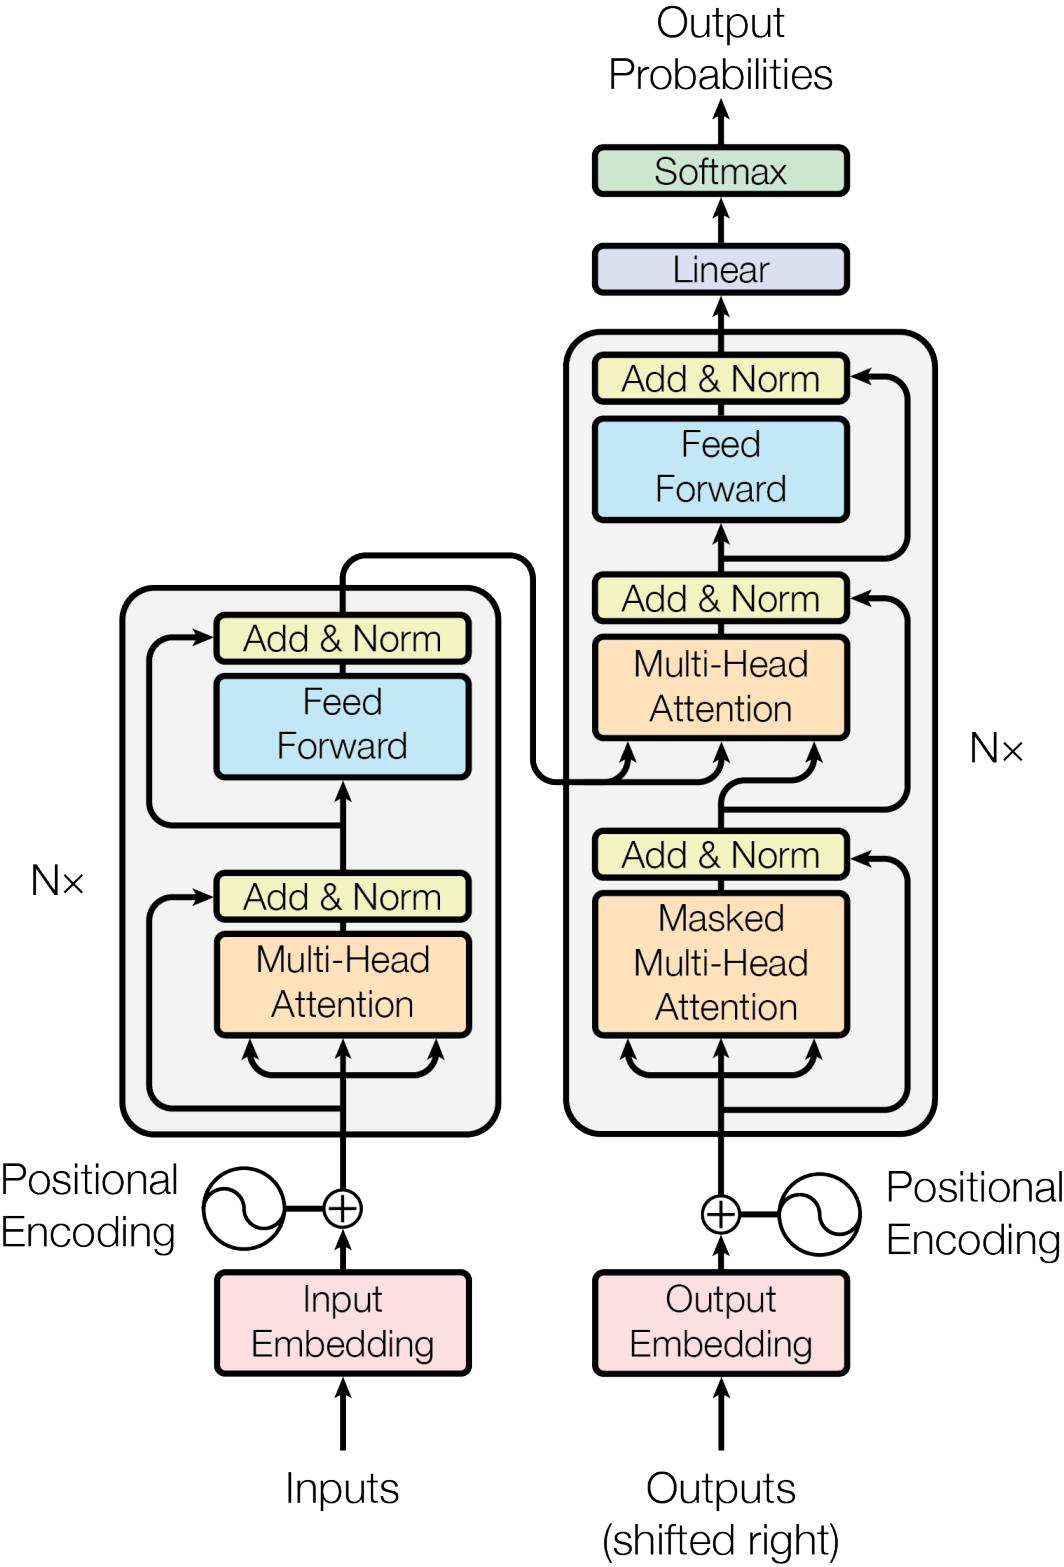

In [7]:
import base64
from IPython.display import Image, display

def display_base64_image(base64_code):
    # Decode the base64 string to binary
    image_data = base64.b64decode(base64_code)
    # Display the image
    display(Image(data=image_data))

display_base64_image(images[0])

## Summarize the data

Create a summary of each element extracted from the PDF. This summary will be vectorized and used in the retrieval process.

### Text and Table summaries

We don't need a multimodal model to generate the summaries of the tables and the text. I will use open source models available on Groq.

In [8]:
from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [9]:
# Prompt
prompt_text = """
You are an assistant tasked with summarizing tables and text.
Give a concise summary of the table or text.

Respond only with the summary, no additionnal comment.
Do not start your message by saying "Here is a summary" or anything like that.
Just give the summary as it is.

Table or text chunk: {element}

"""
prompt = ChatPromptTemplate.from_template(prompt_text)

# Summary chain
model = ChatOllama(temperature=0.5, model="llama3.2:3b ")
summarize_chain = {"element": lambda x: x} | prompt | model | StrOutputParser()

In [10]:
# Summarize text
text_summaries = summarize_chain.batch(texts, {"max_concurrency": 3})

# Summarize tables
tables_html = [table.metadata.text_as_html for table in tables]
table_summaries = summarize_chain.batch(tables_html, {"max_concurrency": 3})

In [11]:
text_summaries

['Researchers at Google propose the Transformer model, a simple network architecture based solely on attention mechanisms, which outperforms complex recurrent or convolutional neural networks in machine translation tasks, achieving state-of-the-art results in English-to-German and English-to-French translation tasks.',
 'The Transformer model relies on self-attention to compute representations of input and output sequences, reducing computational complexity compared to traditional sequence-aligned RNNs and convolutional neural networks.',
 'The Transformer model architecture consists of two stacks of 6 identical layers: an encoder stack and a decoder stack. The encoder stack uses multi-head self-attention and fully connected feed-forward networks with residual connections and layer normalization. The decoder stack adds a third sub-layer performing multi-head attention over the output of the encoder stack, with modifications to prevent positions from attending to subsequent positions.',

### Image summaries

We will use gpt-4o-mini to produce the image summaries.

In [12]:
from langchain_ollama import ChatOllama

prompt_template = """Describe the image in detail. For context,
                  the image is part of a research paper explaining the transformers
                  architecture. Be specific about graphs, such as bar plots."""
messages = [
    (
        "user",
        [
            {"type": "text", "text": prompt_template},
            {
                "type": "image_url",
                "image_url": {"url": "data:image/jpeg;base64,{image}"},
            },
        ],
    )
]

prompt = ChatPromptTemplate.from_messages(messages)

chain = prompt | ChatOllama(model="llava ") | StrOutputParser()


image_summaries = chain.batch(images)

In [13]:
image_summaries

[' The image is a detailed diagram explaining the architecture of a Transformer model. It is a black and white diagram, which provides an overview of the Transformer architecture in the field of Natural Language Processing (NLP).\n\nThe diagram is divided into two main parts. On the left side, there is a block labeled "Input Embedding", which represents the initial step of converting text into numerical vectors. The right side of the diagram shows the "Output Embedding", which is the final step where the model outputs text data.\n\nThe center of the diagram contains the "Transformer" block. This is the core component of the architecture, which is responsible for processing the input text, performing multiple attention heads, and generating the output text.\n\nThe diagram also includes a "Feedforward Network (FFNN)" block, which is a neural network component that is applied to the Transformer model. It is connected to the "Transformer" block, indicating that the FFNN is part of the over

In [14]:
print(image_summaries[1])

 The image provided is a graphical representation of the Transformer architecture, which is a fundamental component of the BERT language model. This architecture is used in natural language processing tasks.

The Transformer architecture is depicted in a flowchart-like layout, with each block representing a different layer or component of the transformer. The blocks are connected by arrows, indicating the flow of data through the network.

Here's a detailed description of the components and their order in the architecture:

1. **Input Embeddings**: This is the first stage in the pipeline, where input words are converted into vectors using an embedding matrix.

2. **Positional Encoding**: This component adds positional information to the input embeddings, allowing the model to understand the position of each word in the sentence.

3. **Encoder**: The encoder is composed of several sub-layers:
   - **Self-Attention**: This layer allows the model to focus on different parts of the input s

## Load data and summaries to vectorstore

### Create the vectorstore

In [15]:
import uuid
from pathlib import Path
from langchain_classic.vectorstores import Chroma
from langchain_classic.storage import InMemoryStore
from langchain_classic.schema.document import Document
from langchain_classic.retrievers.multi_vector import MultiVectorRetriever
from langchain_ollama import OllamaEmbeddings

# Persistent RAG export directory
RAG_DIR = Path("../data/rag_export")
CHROMA_DIR = RAG_DIR / "chroma"
RAG_DIR.mkdir(parents=True, exist_ok=True)
CHROMA_DIR.mkdir(parents=True, exist_ok=True)

# Local embedding model
embeddings = OllamaEmbeddings(model="nomic-embed-text")

# IMPORTANT: Chroma must have a persist_directory.
# Without it, the vector index exists only in memory.
vectorstore = Chroma(
    collection_name="multi_modal_rag",
    embedding_function=embeddings,
    persist_directory=str(CHROMA_DIR),
)

# Parent documents/elements are kept in memory during the notebook run.
store = InMemoryStore()
id_key = "doc_id"

retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=store,
    id_key=id_key,
)

print("Persistent Chroma directory:", CHROMA_DIR.resolve())
print("Collection:", "multi_modal_rag")


C:\Users\HYH\AppData\Local\Temp\ipykernel_15240\3916847233.py:20: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vectorstore = Chroma(


Persistent Chroma directory: D:\Honda\ITI-AI2\Project\data\rag_export\chroma
Collection: multi_modal_rag


### Load the summaries and link the to the original data

In [16]:
# Add texts
doc_ids = [str(uuid.uuid4()) for _ in texts]
summary_texts = [
    Document(page_content=summary, metadata={id_key: doc_ids[i]}) for i, summary in enumerate(text_summaries)
]
retriever.vectorstore.add_documents(summary_texts)
retriever.docstore.mset(list(zip(doc_ids, texts)))

# Add tables
table_ids = [str(uuid.uuid4()) for _ in tables]
summary_tables = [
    Document(page_content=summary, metadata={id_key: table_ids[i]}) for i, summary in enumerate(table_summaries)
]
retriever.vectorstore.add_documents(summary_tables)
retriever.docstore.mset(list(zip(table_ids, tables)))

# Add image summaries
img_ids = [str(uuid.uuid4()) for _ in images]
summary_img = [
    Document(page_content=summary, metadata={id_key: img_ids[i]}) for i, summary in enumerate(image_summaries)
]
retriever.vectorstore.add_documents(summary_img)
retriever.docstore.mset(list(zip(img_ids, images)))

### Check retrieval

In [17]:
# Retrieve
docs = retriever.invoke(
    "who are the authors of the paper?"
)

In [18]:
for doc in docs:
    print(str(doc) + "\n\n" + "-" * 80)

bottoms of the encoder and decoder stacks. The positional encodings have the same dimension dmodel as the embeddings, so that the two can be summed. There are many choices of positional encodings, learned and ﬁxed [8].

In this work, we use sine and cosine functions of different frequencies:

PE(pos,2i) = sin(pos/100002i/dmodel) PE(pos,2i+1) = cos(pos/100002i/dmodel)

where pos is the position and i is the dimension. That is, each dimension of the positional encoding corresponds to a sinusoid. The wavelengths form a geometric progression from 2π to 10000 · 2π. We chose this function because we hypothesized it would allow the model to easily learn to attend by relative positions, since for any ﬁxed offset k, PEpos+k can be represented as a linear function of PEpos.

We also experimented with using learned positional embeddings [8] instead, and found that the two versions produced nearly identical results (see Table 3 row (E)). We chose the sinusoidal version because it may allow the mod

## RAG pipeline

In [19]:
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.messages import HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import ChatOllama
from base64 import b64decode


def parse_docs(docs):
    """Separate base64 image strings from original text/table elements."""
    b64 = []
    text = []

    for doc in docs:
        if isinstance(doc, str):
            try:
                b64decode(doc, validate=True)
                b64.append(doc)
                continue
            except Exception:
                pass

        text.append(doc)

    return {"images": b64, "texts": text}


def element_text(element):
    """Get text safely from Unstructured elements or LangChain Documents."""
    if hasattr(element, "page_content"):
        return element.page_content
    if hasattr(element, "text"):
        return element.text
    return str(element)


def build_prompt(kwargs):
    docs_by_type = kwargs["context"]
    user_question = kwargs["question"]

    context_parts = []

    for text_element in docs_by_type["texts"]:
        context_parts.append(element_text(text_element))

    context_text = "\n\n".join(context_parts)

    prompt_template = f"""
Answer the question using ONLY the following retrieved context.
If the context does not contain the answer, say that you do not know.

Retrieved context:
{context_text}

Question:
{user_question}
"""

    prompt_content = [{"type": "text", "text": prompt_template}]

    for image in docs_by_type["images"]:
        prompt_content.append(
            {
                "type": "image_url",
                "image_url": {"url": f"data:image/jpeg;base64,{image}"},
            }
        )

    return [HumanMessage(content=prompt_content)]


llm = ChatOllama(model="llava", temperature=0)

chain = (
    {
        "context": retriever | RunnableLambda(parse_docs),
        "question": RunnablePassthrough(),
    }
    | RunnableLambda(build_prompt)
    | llm
    | StrOutputParser()
)

chain_with_sources = {
    "context": retriever | RunnableLambda(parse_docs),
    "question": RunnablePassthrough(),
} | RunnablePassthrough().assign(
    response=(
        RunnableLambda(build_prompt)
        | llm
        | StrOutputParser()
    )
)


In [24]:
# Retrieval diagnostic — run this BEFORE saving the RAG.
# If this returns relevant chunks, the retrieval layer is working.
query = "What is the transformer architecture ?"

retrieved_docs = retriever.invoke(query)

print(f"Retrieved {len(retrieved_docs)} parent documents/elements.\n")

for i, doc in enumerate(retrieved_docs, start=1):
    print("=" * 80)
    print("RESULT", i)
    print("TYPE:", type(doc).__name__)
    print("PAGE:", getattr(getattr(doc, "metadata", {}), "get", lambda *_: None)("page_number"))
    print("TEXT:")
    print(element_text(doc)[:1200])
    print()


Retrieved 4 parent documents/elements.

RESULT 1
TYPE: CompositeElement
PAGE: None
TEXT:
3.1 Encoder and Decoder Stacks

Encoder: The encoder is composed of a stack of N = 6 identical layers. Each layer has two sub-layers. The ﬁrst is a multi-head self-attention mechanism, and the second is a simple, position-

2

Output Probabilities Add & Norm Feed Forward Add & Norm Multi-Head Attention a, Add & Norm Nx Add & Norm Feed Forward Nx | —-Casda Nom] Add & Norm VWEeea Multi-Head Multi-Head Attention Attention Sy ae, SE a, Positional CY Encoding ® Positional @ q Encoding Input Embedding Inputs Outputs (shifted right) Output Embedding

Figure 1: The Transformer - model architecture.

wise fully connected feed-forward network. We employ a residual connection [10] around each of the two sub-layers, followed by layer normalization [1]. That is, the output of each sub-layer is LayerNorm(x + Sublayer(x)), where Sublayer(x) is the function implemented by the sub-layer itself. To facilitate these 

In [21]:
response = chain.invoke(
    "What is the attention mechanism?"
)

print(response)

 The attention mechanism is a component of the Transformer model architecture that allows for modeling of dependencies between input and output sequences without regard to their distance in the input or output sequences. It is an integral part of compelling sequence modeling and transduction models in various tasks. The Transformer model architecture eschews recurrence and instead relies entirely on the attention mechanism to draw global dependencies between input and output. 


In [22]:
response = chain_with_sources.invoke(
    "What is transformer architecture?"
)

print("Response:", response['response'])

print("\n\nContext:")
for text in response['context']['texts']:
    print(text.text)
    print("Page number: ", text.metadata.page_number)
    print("\n" + "-"*50 + "\n")
for image in response['context']['images']:
    display_base64_image(image)

ResponseError: {"error":{"code":400,"message":"request (4302 tokens) exceeds the available context size (4096 tokens), try increasing it","type":"exceed_context_size_error","n_prompt_tokens":4302,"n_ctx":4096}} (status code: 400)

## References

- [LangChain Inspiration](https://github.com/langchain-ai/langchain/blob/master/cookbook/Semi_structured_and_multi_modal_RAG.ipynb?ref=blog.langchain.dev)
- [Multivector Storage](https://python.langchain.com/docs/how_to/multi_vector/)

In [ ]:
# ============================================================
# FINAL CELL — SAVE THE COMPLETE RAG
# ============================================================
#
# This saves BOTH parts of the MultiVector RAG:
# 1. Chroma child-summary embeddings
# 2. Parent documents/elements used to build the final context
#
# The embedding model and collection configuration are saved too.

from pathlib import Path
import json
import pickle

RAG_DIR = Path("../data/rag_export")
CHROMA_DIR = RAG_DIR / "chroma"
RAG_DIR.mkdir(parents=True, exist_ok=True)

# Chroma is already persistent because it was initialized with
# persist_directory=CHROMA_DIR.
# Keep this call for older Chroma versions that expose persist().
if hasattr(vectorstore, "persist"):
    try:
        vectorstore.persist()
    except Exception:
        pass

# Save the parent store. InMemoryStore keeps its values in .store.
with open(RAG_DIR / "parent_store.pkl", "wb") as f:
    pickle.dump(store.store, f)

# Save everything needed to reconstruct the RAG later.
config = {
    "collection_name": "multi_modal_rag",
    "id_key": id_key,
    "embedding_model": "nomic-embed-text",
    "llm_model": "llava",
    "rag_type": "MultiVectorRetriever",
    "vector_store": "Chroma",
    "chroma_directory": "chroma",
    "parent_store_file": "parent_store.pkl",
}

with open(RAG_DIR / "rag_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

print("RAG SAVED SUCCESSFULLY")
print("Location:", RAG_DIR.resolve())
print()
print("Files:")
for p in sorted(RAG_DIR.rglob("*")):
    if p.is_file():
        print(" -", p.relative_to(RAG_DIR))
